In [1]:
# Project Title - OpenIntro Possum – Regression
# Outcome Description - The aim of this project is to predict the head length (or age) of brushtail possums using other physical attributes such as total body length, tail length, skull width, chest girth, belly girth, and sex. Since the target variable is continuous, a regression algorithm is used.
# Algorithm Type - Linear Regression  

In [2]:
# Step 1 — Import Libraries
# dataset handling -> pandas
# calculations -> numpy
# visualization -> matplotlib and seaborn
# preprocessing -> regression → sklearn

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
# STEP 2 — Load Dataset

# dataset loading -> pandas (read_csv)
# column cleaning -> strip()
# preview -> head(), columns
# Dataset was loaded using pandas from possum.csv.

# Extra spaces in column names were removed using strip()
# to avoid errors in later steps.

# First 5 rows and column names were displayed
# to understand dataset structure and target column (hdlngth).

In [5]:
df = pd.read_csv("possum.csv")

# Fix column spacing (very important)
df.columns = df.columns.str.strip()

print(df.head())
print(df.columns)

   case  site  Pop sex  age  hdlngth  skullw  totlngth  taill  footlgth  \
0     1     1  Vic   m  8.0     94.1    60.4      89.0   36.0      74.5   
1     2     1  Vic   f  6.0     92.5    57.6      91.5   36.5      72.5   
2     3     1  Vic   f  6.0     94.0    60.0      95.5   39.0      75.4   
3     4     1  Vic   f  6.0     93.2    57.1      92.0   38.0      76.1   
4     5     1  Vic   f  2.0     91.5    56.3      85.5   36.0      71.0   

   earconch   eye  chest  belly  
0      54.5  15.2   28.0   36.0  
1      51.2  16.0   28.5   33.0  
2      51.9  15.5   30.0   34.0  
3      52.2  15.2   28.0   34.0  
4      53.2  15.1   28.5   33.0  
Index(['case', 'site', 'Pop', 'sex', 'age', 'hdlngth', 'skullw', 'totlngth',
       'taill', 'footlgth', 'earconch', 'eye', 'chest', 'belly'],
      dtype='str')


In [6]:
# STEP 3 — Select Columns

# feature selection -> important predictors
# target selection -> regression output

# -->Important columns were selected for regression.

# Features used:
# totlngth, taill, skullw, chest, belly, sex

# Target used:
# hdlngth (Head Length)

# Only selected columns were copied into a new dataset (df_model)
# to avoid unnecessary data and improve model performance.

In [7]:
features = ['totlngth', 'taill', 'skullw', 'chest', 'belly', 'sex']
target = 'hdlngth'

df_model = df[features + [target]].copy()


In [8]:
# STEP 4 — Handling Missing Values

# missing value check -> isnull().sum()
# numerical fill -> mean
# categorical fill -> mode

# --> Missing values were checked in selected columns.

# Numerical columns (totlngth, taill, skullw, chest, belly, hdlngth)
# were filled using mean imputation.

# Categorical column (sex)
# was filled using mode (most frequent value).

# This ensures clean and complete data for regression.

In [9]:
print(df_model.isnull().sum())

num_cols = ['totlngth', 'taill', 'skullw', 'chest', 'belly', 'hdlngth']

for col in num_cols:
    df_model[col] = df_model[col].fillna(df_model[col].mean())

df_model['sex'] = df_model['sex'].fillna(df_model['sex'].mode()[0])


totlngth    0
taill       0
skullw      0
chest       0
belly       0
sex         0
hdlngth     0
dtype: int64


In [10]:
# STEP 5 — Encoding Categorical Variable

# categorical conversion -> numeric
# method -> LabelEncoder

# --> The categorical column (sex) was converted into numeric form.

# LabelEncoder was used to transform:
# m → 1, f → 0
# This allows the regression model to process categorical data properly.

In [11]:
le = LabelEncoder()
df_model['sex'] = le.fit_transform(df_model['sex'])

In [12]:
# STEP 6 — Handling Outliers

# outlier detection -> IQR method
# limit setting -> lower & upper bound
# treatment -> capping

# --> Outliers were handled using the IQR (Interquartile Range) method.

# Q1 (25%) and Q3 (75%) were calculated for each numerical column.
# IQR = Q3 − Q1 was used to find lower and upper limits.

# Values outside the limits were capped
# to reduce the effect of extreme values on regression.

# Columns used:
# totlngth, taill, skullw, chest, belly, hdlngth

In [13]:
num_cols = ['totlngth', 'taill', 'skullw', 'chest', 'belly', 'hdlngth']

for col in num_cols:
    Q1 = df_model[col].quantile(0.25)
    Q3 = df_model[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_model[col] = np.where(df_model[col] > upper, upper, df_model[col])
    df_model[col] = np.where(df_model[col] < lower, lower, df_model[col])


In [14]:
# STEP 7 — Feature Scaling

# feature-target split -> X, y
# scaling method -> StandardScaler

# --> Features (X) and target (y) were separated for regression.

# StandardScaler was applied on feature columns
# to bring all values into the same range.

# This prevents large-value features from dominating the model
# and improves regression performance.

# Features scaled:
# totlngth, taill, skullw, chest, belly, sex

In [15]:
X = df_model[features]
y = df_model[target]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [16]:
# STEP 8 — Handling Imbalanced Dataset

# imbalance check -> describe()

# --> Since this is a regression problem, imbalance is less critical.

# Target variable (hdlngth) distribution was checked using describe()
# to understand range, mean, and spread of values.

# No special balancing technique was required
# as values were reasonably distributed.

In [17]:
print(y.describe())

count    104.000000
mean      92.584615
std        3.418078
min       84.600000
25%       90.675000
50%       92.800000
75%       94.725000
max      100.800000
Name: hdlngth, dtype: float64


In [18]:
# STEP 9 — Train-Test Split

# data split -> training & testing
# ratio -> 80:20

# --> Dataset was split into training and testing sets.

# 80% data was used for training
# and 20% for testing the model.

# random_state=42 ensures same split every time.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

In [20]:
# STEP 10 — Train Model

# algorithm -> Linear Regression
# training -> fit()

# --> Linear Regression model was used for prediction.

# Model was trained using X_train and y_train
# to learn relationship between features and target.

In [21]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [22]:
# STEP 11 — Prediction

# prediction -> predict()

# --> Trained model was used to predict values on test data.

# Predicted values (y_pred) were generated
# to compare with actual values.

In [23]:
y_pred = model.predict(X_test)

In [24]:
# STEP 12 — Model Evaluation

# evaluation metrics -> MSE, R2 Score

# --> Model performance was evaluated using MSE and R2 Score.

# MSE (Mean Squared Error) measures prediction error.
# Lower MSE indicates better model performance.

# R2 Score shows how well the model fits the data.
# Higher R2 means better prediction accuracy.

In [25]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2 Score:", r2)

MSE: 3.0716336206060153
R2 Score: 0.5967424722286632


In [26]:
# STEP 13 — Visualization

# visualization -> scatter plot
# comparison -> actual vs predicted

# --> Scatter plot was used to compare actual and predicted values.

# X-axis shows actual head length
# Y-axis shows predicted head length.

# Points closer to diagonal indicate better model performance.

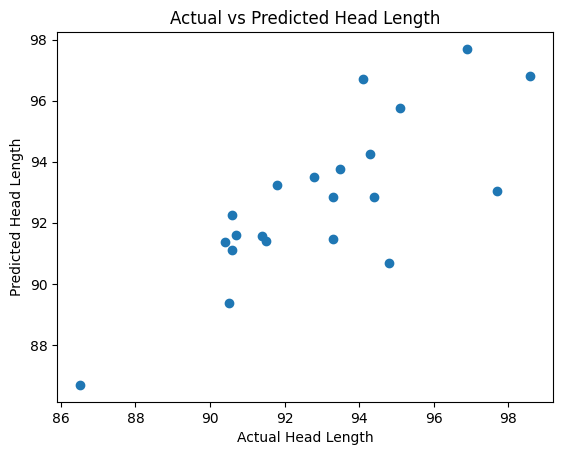

In [27]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Head Length")
plt.ylabel("Predicted Head Length")
plt.title("Actual vs Predicted Head Length")
plt.show()

In [28]:
# STEP 14 — Custom Input Prediction

# user input -> measurements
# preprocessing -> encoding + scaling
# prediction -> model

# --> User entered possum measurements manually.

# Sex input was encoded same as training (male=1, female=0).

# Input values were converted into DataFrame
# and scaled using the trained scaler.

# Final prediction was generated using trained model
# to estimate head length.

In [29]:
print("\nEnter Possum Measurements:")

# Take user input
totalL = float(input("Enter Total Body Length (cm): "))
tailL  = float(input("Enter Tail Length (cm): "))
skullW = float(input("Enter Skull Width (mm): "))
chest  = float(input("Enter Chest Girth (cm): "))
belly  = float(input("Enter Belly Girth (cm): "))
sex_input = input("Enter Sex (male/female): ").lower()

# Encode sex same as training step (f=0, m=1)
sex = 1 if sex_input == "male" else 0

# Show entered values
print("\nEntered Values:")
print(f"  Total Length : {totalL}")
print(f"  Tail Length  : {tailL}")
print(f"  Skull Width  : {skullW}")
print(f"  Chest Girth  : {chest}")
print(f"  Belly Girth  : {belly}")
print(f"  Sex          : {sex_input}")

# Put values into DataFrame
import pandas as pd
custom_data = pd.DataFrame([[totalL, tailL, skullW, chest, belly, sex]], columns=features)

# Apply scaling (IMPORTANT)
custom_scaled = scaler.transform(custom_data)

# Predict
prediction = model.predict(custom_scaled)

print("\n Predicted Head Length:", round(prediction[0], 2), "mm")





Enter Possum Measurements:


ValueError: could not convert string to float: ''

In [ ]:
# STEP 15 — Save Prediction Output

# output storage -> DataFrame
# file saving -> CSV

# --> Predicted result and input values were stored in a DataFrame.

# Output was saved into prediction_output.csv file.

# If file already exists, new data was appended.
# Otherwise, a new file was created.

# This helps keep record of predictions for future use.

In [ ]:
import os
import pandas as pd

output = pd.DataFrame({
    "Total Length"         : [totalL],
    "Tail Length"          : [tailL],
    "Skull Width"          : [skullW],
    "Chest Girth"          : [chest],
    "Belly Girth"          : [belly],
    "Sex"                  : [sex_input],
    "Predicted Head Length": [round(prediction[0], 2)]
})

file_name = "prediction_output.csv"
if os.path.exists(file_name):
    output.to_csv(file_name, mode='a', header=False, index=False)
else:
    output.to_csv(file_name, index=False)

print(" Prediction saved to prediction_output.csv")
print(output)

 Prediction saved to prediction_output.csv
   Total Length  Tail Length  Skull Width  Chest Girth  Belly Girth     Sex  \
0          87.0         30.0         50.0         36.0         35.0  female   

   Predicted Head Length  
0                  90.71  
